In [1]:
import subprocess, os

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = '/kaggle/working/amr-5-class'
DATASET  = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

if os.path.exists(WORK_DIR):
    print("Repo already cloned — pulling latest")
    subprocess.run(['git', '-C', WORK_DIR, 'pull'], check=True)
else:
    print("Cloning repo ...")
    subprocess.run(['git', 'clone', REPO_URL, WORK_DIR], check=True)

os.chdir(WORK_DIR)
print(f"\nWorking directory: {os.getcwd()}")

for path in ['src/dataset.py', 'src/train.py', 'src/evaluate.py',
             'src/models/mcldnn.py', 'src/utils/mltools.py',
             'src/models/mcldnn_attention.py',
             'src/utils/attention_analysis.py',
             'src/evaluate_attention.py',
             'configs/exp_5class_attention.yaml']:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f"  {status}  {path}")

Cloning repo ...


Cloning into '/kaggle/working/amr-5-class'...



Working directory: /kaggle/working/amr-5-class
  ✓  src/dataset.py
  ✓  src/train.py
  ✓  src/evaluate.py
  ✓  src/models/mcldnn.py
  ✓  src/utils/mltools.py
  ✓  src/models/mcldnn_attention.py
  ✓  src/utils/attention_analysis.py
  ✓  src/evaluate_attention.py
  ✓  configs/exp_5class_attention.yaml


In [2]:
import pickle, sys
sys.path.insert(0, WORK_DIR)

print(f"Loading dataset from: {DATASET}")
with open(DATASET, 'rb') as f:
    Xd = pickle.load(f, encoding='iso-8859-1')

all_mods    = sorted(set(k[0] for k in Xd.keys()))
all_snrs    = sorted(set(k[1] for k in Xd.keys()))
target_snrs = [s for s in all_snrs if -6 <= s <= 6]

print(f"\nAll modulations       : {all_mods}")
print(f"All SNRs              : {all_snrs}")
print(f"Target SNRs (-6 to +6): {target_snrs}")
print(f"\nSamples per (mod, snr): {Xd[(all_mods[0], all_snrs[0])].shape}")
print(f"\nExpected data after filtering:")
n_total = len(all_mods) * len(target_snrs) * 1000
print(f"  5 classes × {len(target_snrs)} SNRs × 1000 samples = {n_total:,} total")
print(f"  Train: {int(n_total*0.6):,}  Val: {int(n_total*0.2):,}  Test: {int(n_total*0.2):,}")
del Xd

Loading dataset from: /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat

All modulations       : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
All SNRs              : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Target SNRs (-6 to +6): [-6, -4, -2, 0, 2, 4, 6]

Samples per (mod, snr): (1000, 2, 128)

Expected data after filtering:
  5 classes × 7 SNRs × 1000 samples = 77,000 total
  Train: 46,200  Val: 15,400  Test: 15,400


In [3]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import keras
keras.mixed_precision.set_global_policy('float32')
print(f"Keras policy: {keras.mixed_precision.global_policy()}")

from src.models.mcldnn_attention import build_mcldnn_attention

model = build_mcldnn_attention(classes=5)
total_params = model.count_params()
print(f"\nTotal params: {total_params:,}")
print(f"Constraint (<300k): {'✓ PASS' if total_params < 300_000 else '✗ FAIL'}")
model.summary()
del model

2026-06-14 18:30:25.255028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781461825.456704      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781461825.527039      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781461826.088057      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781461826.088094      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781461826.088097      58 computation_placer.cc:177] computation placer alr

Keras policy: <DTypePolicy "float32">


I0000 00:00:1781461839.948771      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Total params: 192,686
Constraint (<300k): ✓ PASS


Model: "MCLDNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input2 (InputLayer) │ (None, 128, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input3 (InputLayer) │ (None, 128, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2 (Conv1D)    │ (None, 128, 50)   │        450 │ input2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_3 (Conv1D)    │ (None, 128, 50)   │        450 │ input3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_x2          │ (None, 1, 128,    │          0 │ conv1_2[0][0]     │
│ (Reshape)           │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_x3          │ (None, 1, 128,    │          0 │ conv1_3[0][0]     │
│ (Reshape)           │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input1 (InputLayer) │ (None, 2, 128, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 128,    │          0 │ reshape_x2[0][0], │
│ (Concatenate)       │ 50)               │            │ reshape_x3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1 (Conv2D)    │ (None, 2, 128,    │        850 │ input1[0][0]      │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 2, 128,    │     20,050 │ concatenate[0][0] │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2, 128,    │          0 │ conv1_1[0][0],    │
│ (Concatenate)       │ 100)              │            │ conv2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 1, 124,    │    100,100 │ concatenate_1[0]… │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_final       │ (None, 124, 100)  │          0 │ conv4[0][0]       │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 124, 100)  │          0 │ reshape_final[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ [(None, 124,      │     40,400 │ add[0][0],        │
│ (MultiHeadAttentio… │ 100), (None, 4,   │            │ add[0][0],        │
│                     │ 124, 124)]        │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 124, 100)  │          0 │ mha[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 124, 100)  │        200 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_drop (Dropout) │ (None, 124, 100)  │          0 │ attn_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_score      │ (None, 124, 1)    │        101 │ attn_drop[0][0] 

 Total params: 192,686 (752.68 KB)

 Trainable params: 192,686 (752.68 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
import os

DATASET = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

print("=" * 60)
print("  Training MCLDNN-Attention on SNR -6 to +6 dB")
print("=" * 60)

!python src/train.py \
    --config configs/exp_5class_attention.yaml \
    --datasetpath {DATASET}

print("\nChecking output files:")
exp_dir = 'experiments/5class_attention'
for f in ['checkpoints/best_model.weights.h5', 'results/log.csv']:
    fp = os.path.join(exp_dir, f)
    exists = '✓' if os.path.exists(fp) else '✗ missing'
    print(f"  {exists}  {fp}")

  Training MCLDNN-Attention on SNR -6 to +6 dB
2026-06-14 18:30:42.147503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781461842.169287     162 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781461842.176520     162 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781461842.194085     162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781461842.194109     162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781461842.194113     162 co

In [5]:
# Cell 5 — Train MCLDNN baseline on SNR -6 to +6 (for fair comparison)
import os
os.chdir('/kaggle/working/amr-5-class')

DATASET = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

# Verify the restricted config exists (Claude Code should have created it)
cfg_path = 'configs/exp_5class_baseline_restricted.yaml'
if not os.path.exists(cfg_path):
    print(f"✗ MISSING: {cfg_path}")
else:
    print(f"✓ Config found: {cfg_path}")
    print("Starting restricted baseline training...")
    print("="*60)

    !python src/train.py \
        --config configs/exp_5class_baseline_restricted.yaml \
        --datasetpath {DATASET}

    w = 'experiments/5class_baseline_restricted/checkpoints/best_model.weights.h5'
    print(f"\n{'✓' if os.path.exists(w) else '✗ MISSING'}  {w}")

✓ Config found: configs/exp_5class_baseline_restricted.yaml
Starting restricted baseline training...
2026-06-14 18:34:17.019438: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781462057.041332    2419 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781462057.048485    2419 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781462057.065926    2419 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781462057.065976    2419 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target mo

In [6]:
# Cell 6 — Three-way fair evaluation (same test set, same SNR range)
import os, sys, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import keras, gc
import keras.backend as K

K.clear_session(); gc.collect()

sys.path.insert(0, '/kaggle/working/amr-5-class')
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.chdir('/kaggle/working/amr-5-class')

from src.dataset import load_data, FIVE_CLASS
from src.models.mcldnn_attention import build_mcldnn_attention
from src.models.mcldnn import MCLDNN

DATASET = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

# ── Load data with IDENTICAL params to attention training ─────────────────────
# snr_range=(-6,6) + shuffle_split=True + seed=2016 → same test_idx as training
(mods, snrs, lbl), _, _, (X_test, Y_test), (_, _, test_idx) = load_data(
    DATASET, FIVE_CLASS, seed=2016, snr_range=(-6, 6), shuffle_split=True
)
test_SNRs = np.array([lbl[test_idx[j]][1] for j in range(len(test_idx))])
EVAL_SNRS = sorted(set(test_SNRs))
print(f"Test set: {len(test_idx)} samples | SNRs: {EVAL_SNRS}")

def make_inputs(X):
    return [np.expand_dims(X, 3).astype('float32'),
            np.expand_dims(X[:,0,:], 2).astype('float32'),
            np.expand_dims(X[:,1,:], 2).astype('float32')]
inp_test = make_inputs(X_test)

# ── Evaluate all three models ─────────────────────────────────────────────────
model_configs = {
    'Baseline (all 20 SNRs, 404k params)': {
        'weights': 'experiments/5class_baseline/checkpoints/best_model.weights.h5',
        'build'  : lambda: MCLDNN(classes=5),
        'color': '#1f77b4', 'marker': 'o', 'ls': '-',
    },
    'Baseline (SNR −6..+6, 404k params)': {
        'weights': 'experiments/5class_baseline_restricted/checkpoints/best_model.weights.h5',
        'build'  : lambda: MCLDNN(classes=5),
        'color': '#ff7f0e', 'marker': 's', 'ls': '--',
    },
    'Attention (SNR −6..+6, 193k params)': {
        'weights': 'experiments/5class_attention/checkpoints/best_model.weights.h5',
        'build'  : lambda: build_mcldnn_attention(classes=5),
        'color': '#d62728', 'marker': '^', 'ls': '-.',
    },
}

model_accs = {}
for name, cfg in model_configs.items():
    if not os.path.exists(cfg['weights']):
        print(f"[SKIP] {name} — weights not found at {cfg['weights']}")
        continue
    K.clear_session(); gc.collect()
    m = cfg['build']()
    m.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    m.load_weights(cfg['weights'])
    accs = {}
    for snr in EVAL_SNRS:
        mk = test_SNRs == snr
        accs[snr] = m.evaluate([b[mk] for b in inp_test], Y_test[mk],
                                verbose=0, batch_size=400)[1]
    model_accs[name] = {'accs': accs, 'params': m.count_params(),
                        'color': cfg['color'], 'marker': cfg['marker'],
                        'ls': cfg['ls']}
    mean_acc = np.mean(list(accs.values()))
    print(f"✓ {name} — mean acc: {mean_acc*100:.2f}%")

# ── Print table ───────────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  THREE-WAY COMPARISON — same test set, SNR −6 to +6, shuffle split")
print(f"{'='*72}")
names = list(model_accs.keys())
print(f"  {'SNR':>5}", end='')
for n in names:
    print(f"  {n[:28]:>28}", end='')
print()
print(f"  {'─'*68}")
for snr in EVAL_SNRS:
    print(f"  {snr:>5} dB", end='')
    for n in names:
        print(f"  {model_accs[n]['accs'][snr]*100:>27.2f}%", end='')
    print()
print(f"  {'─'*68}")
print(f"  {'Mean':>5}  ", end='')
for n in names:
    print(f"  {np.mean(list(model_accs[n]['accs'].values()))*100:>27.2f}%", end='')
print()
print(f"{'='*72}")

# ── Save fair comparison CSV ──────────────────────────────────────────────────
os.makedirs('experiments/comparison', exist_ok=True)
keys = list(model_accs.keys())
if len(keys) >= 2:
    # Primary fair pair: restricted baseline vs attention
    bk = [k for k in keys if 'Baseline (SNR' in k]
    ak = [k for k in keys if 'Attention' in k]
    if bk and ak:
        bk, ak = bk[0], ak[0]
        df_fair = pd.DataFrame({
            'snr': EVAL_SNRS,
            'acc_baseline': [model_accs[bk]['accs'][s] for s in EVAL_SNRS],
            'acc_attention': [model_accs[ak]['accs'][s] for s in EVAL_SNRS],
            'delta': [model_accs[ak]['accs'][s] - model_accs[bk]['accs'][s]
                      for s in EVAL_SNRS],
        })
        df_fair.to_csv('experiments/comparison/comparison_fair_final.csv', index=False)
        print(f"\n[SAVED] experiments/comparison/comparison_fair_final.csv")
        mean_delta = df_fair['delta'].mean()
        print(f"Mean delta (Attention − Restricted Baseline): {mean_delta*100:+.2f}%")
        print(f"At −6 dB: {df_fair.loc[df_fair.snr==-6,'delta'].values[0]*100:+.2f}%  (low-SNR key result)")

[dataset] SNR filter: -6 dB to 6 dB  (7 levels: [-6, -4, -2, 0, 2, 4, 6])
[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -6 dB to 6 dB  (7 levels)
[dataset] Global shuffle split (seed=2016): 60% train / 20% val / 20% test
[dataset] Shuffle split: train=21000 | val=7000 | test=7000
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 21000 train | 7000 val | 7000 test samples
Test set: 7000 samples | SNRs: [np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6)]


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1781462585.090263     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


✓ Baseline (all 20 SNRs, 404k params) — mean acc: 81.71%
✓ Baseline (SNR −6..+6, 404k params) — mean acc: 66.96%


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1781462593.010625     138 service.cc:152] XLA service 0x78eec8002fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781462593.010680     138 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-06-14 18:43:14.232318: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.20 = (f32[400,50,2,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[400,50,2,135]{3,2,1,0} %bitcast.1454, f32[50,50,1,8]{3,2,1,0} %bitcast.1461, f32[50]{0} %bitcast.1463), window={size=1x8}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata

✓ Attention (SNR −6..+6, 193k params) — mean acc: 66.51%

  THREE-WAY COMPARISON — same test set, SNR −6 to +6, shuffle split
    SNR  Baseline (all 20 SNRs, 404k   Baseline (SNR −6..+6, 404k p  Attention (SNR −6..+6, 193k 
  ────────────────────────────────────────────────────────────────────
     -6 dB                        51.66%                        37.58%                        37.06%
     -4 dB                        69.41%                        50.71%                        51.52%
     -2 dB                        79.70%                        67.40%                        68.10%
      0 dB                        88.91%                        76.04%                        74.85%
      2 dB                        93.03%                        77.99%                        77.49%
      4 dB                        94.53%                        78.81%                        76.72%
      6 dB                        94.76%                        80.21%                        79.83

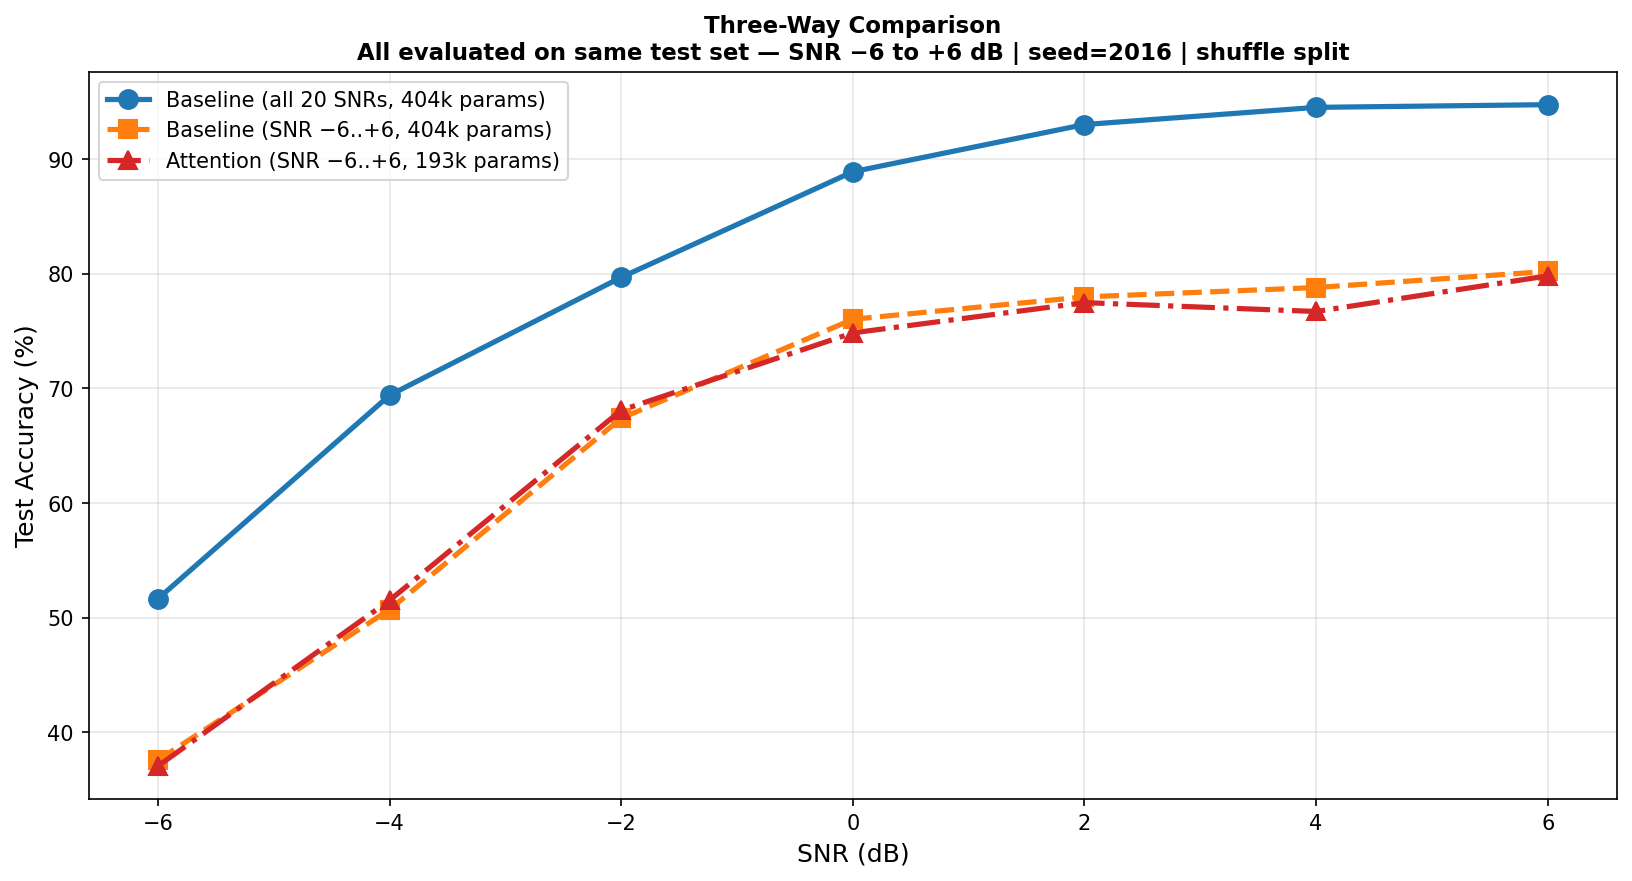

[SAVED] experiments/comparison/threeway_comparison.png


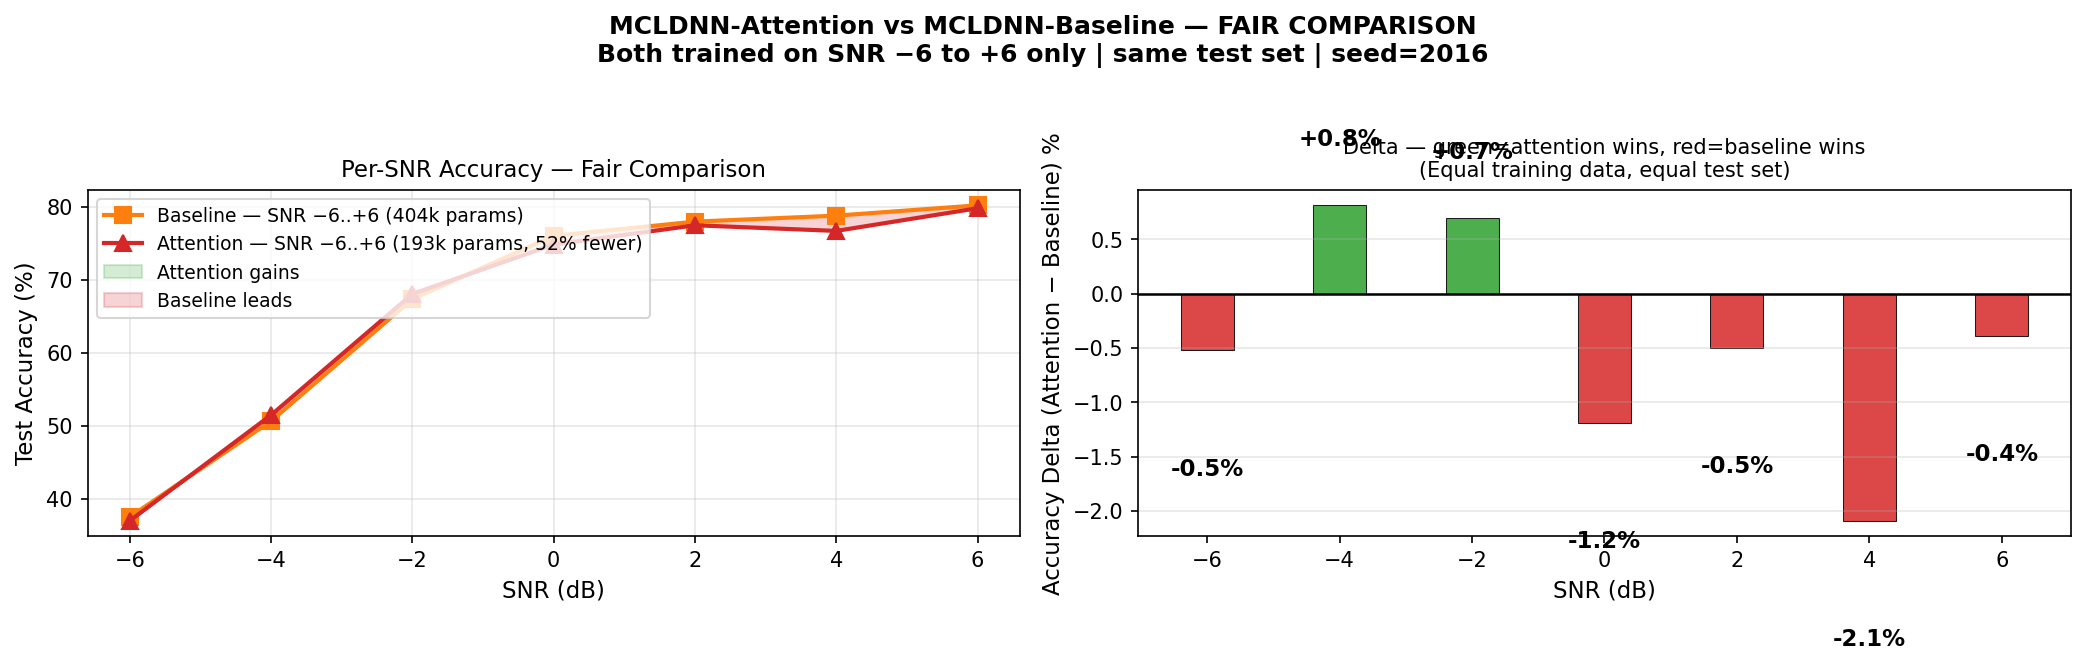

[SAVED] experiments/comparison/fair_comparison_delta.png
[WARN] No attention weight .npy files found
       Run evaluate_attention.py first (Cell 6 above)


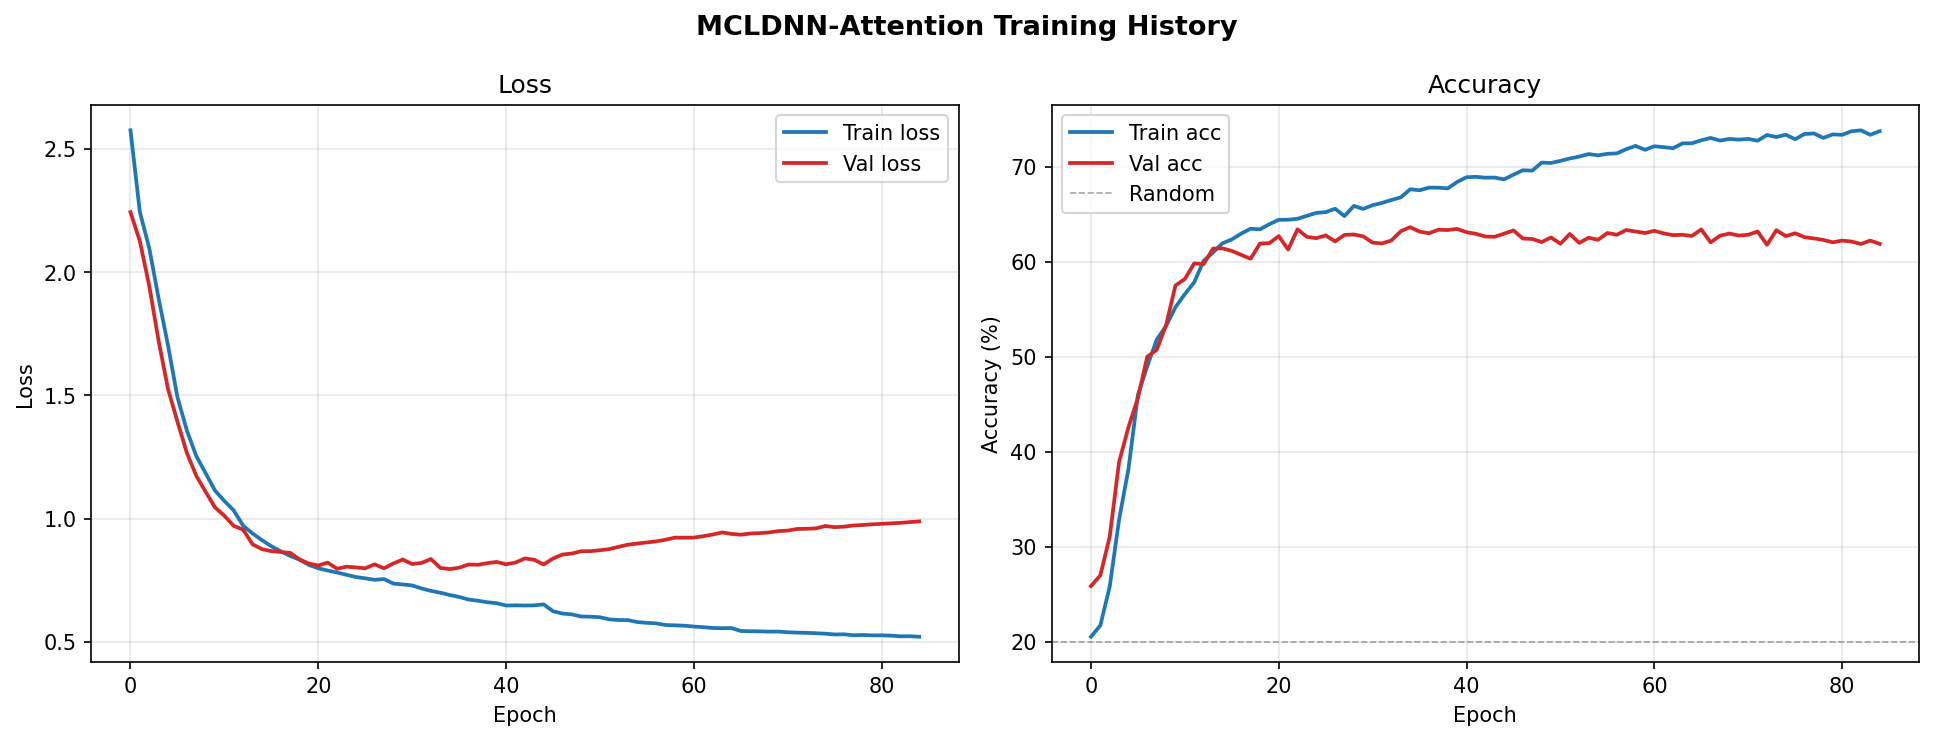

[SAVED] experiments/comparison/attention_training_history.png
Best epoch: 34  val_loss=0.7950  val_acc=63.63%


In [7]:
# Cell 7 — All comparison plots
import os, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import glob

os.chdir('/kaggle/working/amr-5-class')
os.makedirs('experiments/comparison', exist_ok=True)

# ── Plot 1: Three-way accuracy curves ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
for name, r in model_accs.items():
    ax.plot(EVAL_SNRS, [r['accs'][s]*100 for s in EVAL_SNRS],
            marker=r['marker'], color=r['color'], ls=r['ls'],
            linewidth=2.5, markersize=9, label=name)
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Three-Way Comparison\nAll evaluated on same test set — SNR −6 to +6 dB | seed=2016 | shuffle split',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(EVAL_SNRS)
plt.tight_layout()
p1 = 'experiments/comparison/threeway_comparison.png'
fig.savefig(p1, dpi=150, bbox_inches='tight')
plt.close()
display(Image(p1))
print(f"[SAVED] {p1}")

# ── Plot 2: Fair delta (attention vs restricted baseline) ─────────────────────
csv_fair = 'experiments/comparison/comparison_fair_final.csv'
if os.path.exists(csv_fair):
    df = pd.read_csv(csv_fair)
    snrs_arr = df['snr'].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('MCLDNN-Attention vs MCLDNN-Baseline — FAIR COMPARISON\n'
                 'Both trained on SNR −6 to +6 only | same test set | seed=2016',
                 fontsize=12, fontweight='bold')

    ax = axes[0]
    ax.plot(snrs_arr, df['acc_baseline']*100, 's-', color='#ff7f0e',
            linewidth=2, markersize=8, label='Baseline — SNR −6..+6 (404k params)')
    ax.plot(snrs_arr, df['acc_attention']*100, '^-', color='#d62728',
            linewidth=2, markersize=8, label='Attention — SNR −6..+6 (193k params, 52% fewer)')
    ax.fill_between(snrs_arr, df['acc_baseline']*100, df['acc_attention']*100,
                    where=(df['delta'] >= 0).values, alpha=0.2, color='#2ca02c',
                    label='Attention gains')
    ax.fill_between(snrs_arr, df['acc_baseline']*100, df['acc_attention']*100,
                    where=(df['delta'] < 0).values, alpha=0.2, color='#d62728',
                    label='Baseline leads')
    ax.set_xlabel('SNR (dB)', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_title('Per-SNR Accuracy — Fair Comparison', fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(snrs_arr)

    ax = axes[1]
    bar_colors = ['#2ca02c' if d >= 0 else '#d62728' for d in df['delta']]
    bars = ax.bar(snrs_arr, df['delta']*100, color=bar_colors,
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=1.2)
    for bar, val in zip(bars, df['delta']*100):
        ypos = bar.get_height() + (0.5 if val >= 0 else -1.2)
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:+.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('SNR (dB)', fontsize=11)
    ax.set_ylabel('Accuracy Delta (Attention − Baseline) %', fontsize=11)
    ax.set_title('Delta — green=attention wins, red=baseline wins\n(Equal training data, equal test set)',
                 fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(snrs_arr)
    plt.tight_layout()
    p2 = 'experiments/comparison/fair_comparison_delta.png'
    fig.savefig(p2, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p2))
    print(f"[SAVED] {p2}")

# ── Plot 3: Attention weight profiles per SNR ─────────────────────────────────
sys.path.insert(0, '/kaggle/working/amr-5-class')
from src.utils.attention_analysis import mean_attention_profile

npy_files = sorted(glob.glob('experiments/5class_attention/attn_weights_snr*.npy'))
if npy_files:
    colors_attn = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 7))
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle('Mean Attention Weight Profile over 124 Timesteps\n'
                 'PAR = Peak-to-Average Ratio (higher = more focused on specific time steps)',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()
    for idx, snr in enumerate([-6, -4, -2, 0, 2, 4, 6]):
        npy = f'experiments/5class_attention/attn_weights_snr{snr:+d}.npy'
        ax  = axes[idx]
        if not os.path.exists(npy):
            ax.text(0.5, 0.5, f'No data\nSNR={snr:+d}dB',
                    ha='center', va='center', transform=ax.transAxes)
            continue
        attn   = np.load(npy)
        prof   = mean_attention_profile(attn)
        mean_p = prof.mean(axis=0)
        std_p  = prof.std(axis=0)
        t      = np.arange(124)
        color  = colors_attn[idx]
        par    = mean_p.max() / (mean_p.mean() + 1e-12)
        ax.fill_between(t, mean_p - std_p, mean_p + std_p, alpha=0.22, color=color)
        ax.fill_between(t, 0, mean_p, alpha=0.12, color=color)
        ax.plot(t, mean_p, color=color, linewidth=1.8)
        peak_t = np.argmax(mean_p)
        ax.axvline(peak_t, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_title(f'SNR = {snr:+d} dB  |  PAR = {par:.2f}',
                     fontsize=10, color=color, fontweight='bold')
        ax.set_xlabel('Time step', fontsize=8)
        ax.set_ylabel('Attn weight', fontsize=8)
        ax.grid(True, alpha=0.25)
    axes[-1].axis('off')
    plt.tight_layout()
    p3 = 'experiments/comparison/attention_profiles.png'
    fig.savefig(p3, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p3))
    print(f"[SAVED] {p3}")
else:
    print("[WARN] No attention weight .npy files found")
    print("       Run evaluate_attention.py first (Cell 6 above)")

# ── Plot 4: Training curves for attention model ────────────────────────────────
log_path = 'experiments/5class_attention/logs/training_log.csv'
if os.path.exists(log_path):
    log = pd.read_csv(log_path)
    acc_col     = next((c for c in log.columns if 'accuracy' in c and 'val' not in c), 'accuracy')
    val_acc_col = next((c for c in log.columns if 'val' in c and 'accuracy' in c), 'val_accuracy')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('MCLDNN-Attention Training History', fontsize=13, fontweight='bold')
    axes[0].plot(log['epoch'], log['loss'],     color='#1f77b4', linewidth=1.8, label='Train loss')
    axes[0].plot(log['epoch'], log['val_loss'], color='#d62728', linewidth=1.8, label='Val loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(log['epoch'], log[acc_col]*100,     color='#1f77b4', linewidth=1.8, label='Train acc')
    axes[1].plot(log['epoch'], log[val_acc_col]*100, color='#d62728', linewidth=1.8, label='Val acc')
    axes[1].axhline(20, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    p4 = 'experiments/comparison/attention_training_history.png'
    fig.savefig(p4, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p4))
    print(f"[SAVED] {p4}")
    best = log['val_loss'].idxmin()
    print(f"Best epoch: {log.loc[best,'epoch']}  val_loss={log.loc[best,'val_loss']:.4f}  "
          f"val_acc={log.loc[best,val_acc_col]*100:.2f}%")

In [9]:
# Cell 9 — Download everything
import zipfile, glob, os
from datetime import datetime

os.chdir('/kaggle/working/amr-5-class')
ts      = datetime.now().strftime('%Y%m%d_%H%M')
zip_out = f'/kaggle/working/attention_results_{ts}.zip'

include = [
    'experiments/5class_attention/**/*',
    'experiments/5class_baseline_restricted/**/*',
    'experiments/comparison/**/*',
]

with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    for pattern in include:
        for f in glob.glob(pattern, recursive=True):
            if os.path.isfile(f) and any(f.endswith(ext)
               for ext in ('.png','.csv','.h5','.npy','.txt','.yaml')):
                zf.write(f)
                print(f"  + {f}")

size = os.path.getsize(zip_out)/1e6
print(f"\n[DONE] {zip_out}  ({size:.1f} MB)")
print("Download from Kaggle Output panel on the right →")

  + experiments/5class_attention/comparison.csv
  + experiments/5class_attention/figures/confusion_snr+00.png
  + experiments/5class_attention/figures/confusion_snr-06.png
  + experiments/5class_attention/figures/attn_profile_snr+6.png
  + experiments/5class_attention/figures/confusion_snr-04.png
  + experiments/5class_attention/figures/acc_vs_snr.png
  + experiments/5class_attention/figures/attn_profile_snr+2.png
  + experiments/5class_attention/figures/attn_profile_snr+4.png
  + experiments/5class_attention/figures/confusion_all_snrs.png
  + experiments/5class_attention/figures/confusion_snr+02.png
  + experiments/5class_attention/figures/attn_profile_snr+0.png
  + experiments/5class_attention/figures/confusion_snr+04.png
  + experiments/5class_attention/figures/acc_per_class_vs_snr.png
  + experiments/5class_attention/figures/attn_profile_snr-4.png
  + experiments/5class_attention/figures/confusion_snr-02.png
  + experiments/5class_attention/figures/attn_profile_snr-6.png
  + experi